In [1]:
import numpy as np

nx, nz = 2630//10+1, 3640//10+1
path = "gradients/grad_full_0.bin"
fobj = open(path, "rb")
snapsObj_f = np.fromfile(fobj, dtype=np.float32)
fobj.close()
grad0 = snapsObj_f.reshape(nx, nz)

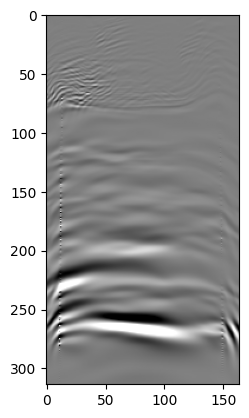

In [2]:
from matplotlib import pyplot as plt
buff = np.diff(grad0.T[:-50, 50:-50], axis=0)
# buff = grad.T[:-50, 50:-50]

qa = np.quantile(buff, 0.99)
plt.imshow(buff, cmap='gray', vmin=-qa, vmax=qa)

In [3]:
import numpy as np

nx, nz = 2630//10+1, 3640//10+1
path = "gradients/grad_full_1.bin"
fobj = open(path, "rb")
snapsObj_f = np.fromfile(fobj, dtype=np.float32)
fobj.close()
grad1 = snapsObj_f.reshape(nx, nz)

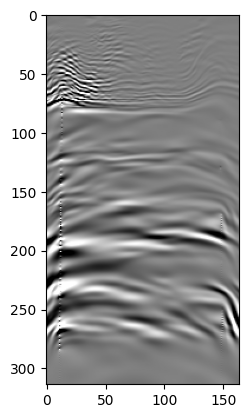

In [5]:
from matplotlib import pyplot as plt
buff = np.diff(grad1.T[:-50, 50:-50], axis=0)
# buff = grad.T[:-50, 50:-50]

qa = np.quantile(buff, 0.99)
plt.imshow(buff, cmap='gray', vmin=-qa, vmax=qa)

In [6]:
grad1-grad0

array([[-2.8208000e-04, -2.8424023e-04, -2.8234965e-04, ...,
        -2.6278052e-04, -2.6914236e-04, -2.7442936e-04],
       [-2.8804701e-04, -2.5121676e-04, -1.8144530e-04, ...,
        -2.6868412e-04, -2.7407357e-04, -2.7781428e-04],
       [-2.8490560e-04, -2.1265227e-04, -9.5511365e-05, ...,
        -2.6282307e-04, -2.6999906e-04, -2.7262999e-04],
       ...,
       [-2.8793991e-04, -2.9193223e-04, -2.9288308e-04, ...,
        -2.6667767e-04, -2.7304632e-04, -2.8023860e-04],
       [-2.7888379e-04, -2.8339616e-04, -2.8640713e-04, ...,
        -2.6113051e-04, -2.6684086e-04, -2.7188612e-04],
       [-2.7918263e-04, -2.8254971e-04, -2.8377611e-04, ...,
        -2.6659851e-04, -2.7065765e-04, -2.7512797e-04]], dtype=float32)

In [29]:
import numpy as np

nx, nz = 2630, 3640
path = "images/image_iter_1.bin"
fobj = open(path, "rb")
snapsObj_f = np.fromfile(fobj)
fobj.close()
grad = snapsObj_f.reshape(nx, nz)

In [30]:
grad.min()

np.float64(-0.05748667842025786)

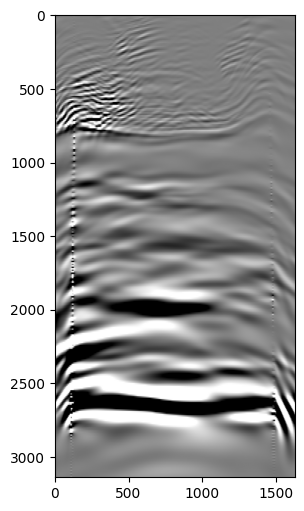

In [31]:
from matplotlib import pyplot as plt
from scipy.ndimage import laplace
buff = np.diff(grad.T[:-500, 500:-500], axis=0)
# buff = laplace(grad.T[:-500, 500:-500])

# buff = grad.T[:-500, 500:-500]

qa = np.quantile(buff, 0.95)
plt.imshow(buff, cmap='gray', vmin=-qa, vmax=qa)
plt.show()

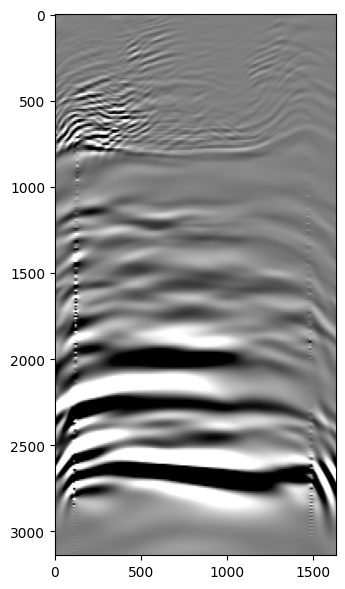

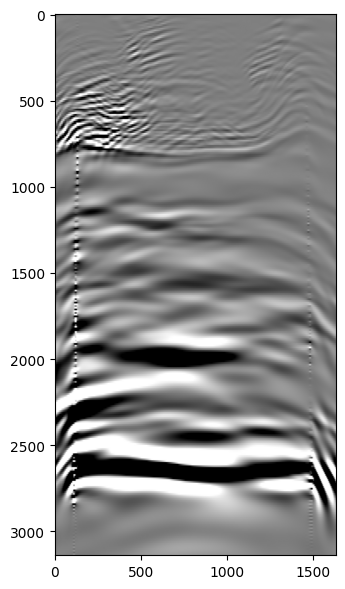

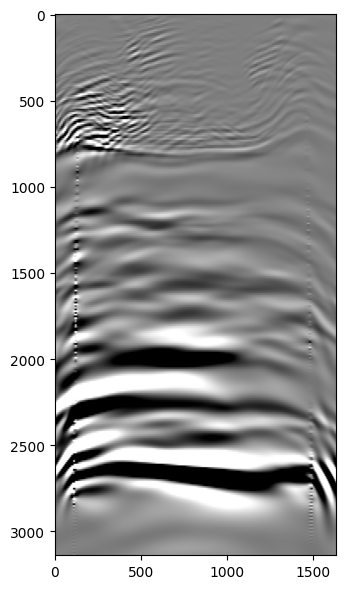

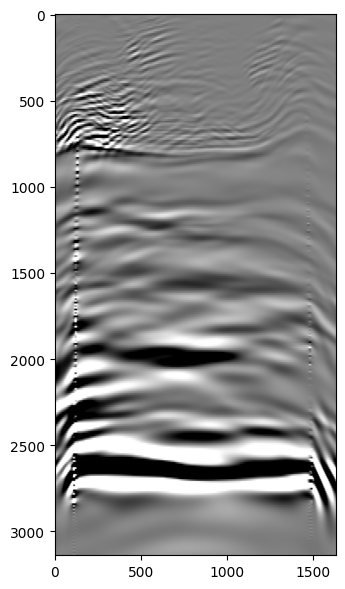

In [51]:
for i in range(4):
    path = f"images/image_iter_{i}.bin"
    fobj = open(path, "rb")
    snapsObj_f = np.fromfile(fobj)
    fobj.close()
    grad = snapsObj_f.reshape(nx, nz)
    buff = np.diff(grad.T[:-500, 500:-500], axis=0)
    # buff = grad.T[:-500, 500:-500]

    qa = np.quantile(buff, 0.95)
    plt.imshow(buff, cmap='gray', vmin=-qa, vmax=qa)
    plt.tight_layout()
    plt.savefig(f"{i}.png")
    plt.show()

In [7]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm
import os
from config import *
import argparse

def setup_model_and_geometry():
    """Set up the velocity model and acquisition geometry"""
    dataset = SeismogramDataset(PATH_DATA, "sou", invert_elevs=True)
    xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
    spacing = (0.025, 0.025)
    
    velmodel = VelocityModel(
        PATH_MODEL,
        dx=spacing[0],
        dz=spacing[1],
        clip=True,
        xmin=xmin - 3,
        xmax=xmax + 3,
        zmin=-318,
    )
    velmodel.pad_left(4 + 2)
    velmodel.pad_right(8 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_bottom(10 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_top(7 * int(0.5 / spacing[0]))

    origin = velmodel.x[0], velmodel.z[0]
    vp = velmodel.vp.T
    
    model = SeismicModel(
        vp=vp,
        origin=origin,
        shape=vp.shape,
        spacing=spacing,
        space_order=SO,
        nbl=NBL,
        bcs="damp",
        fs=False,
    )
    
    return model, dataset

model, dataset = setup_model_and_geometry()

Operator `initdamp` ran in 0.01 s


In [44]:
d_syn = np.fromfile(f"{OUTPUT_DIRS['adjoint_snaps']}/d_syn_{10}.bin", dtype=np.float32)
print(d_syn.shape)

(1282386,)


In [45]:
dataset._dt_r = model.critical_dt
dataset._t_max_r = dataset._t_max
dataset.resample_on()
d_obs = dataset[10][0]
print(d_obs.shape)

(57, 22498)


In [46]:
d_syn_r = np.reshape(d_syn, d_obs.T.shape)
print(d_syn_r.max())

1.7213175


In [47]:
print(np.quantile(d_obs, 0.95))
print(np.quantile(d_syn_r, 0.95))
scale_factor = np.sqrt(np.sum(d_obs.ravel()**2))/np.sqrt(np.sum(d_syn_r.ravel()**2))
print(scale_factor)

1.7441655993461609
0.11032508
14.753540499811029


In [48]:
scale_factor = np.load(f"{OUTPUT_DIRS['forward_snaps']}/scale_factor_{10}.npy")

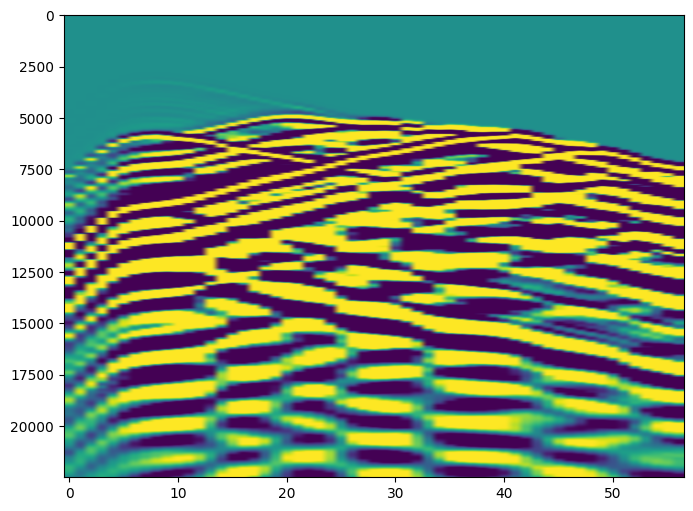

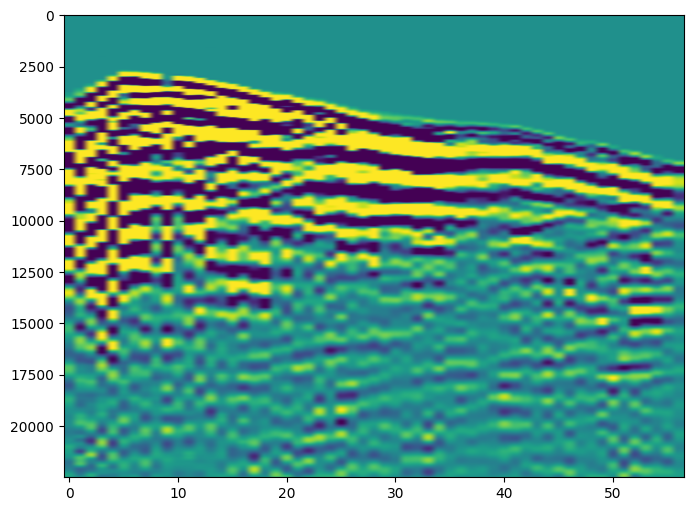

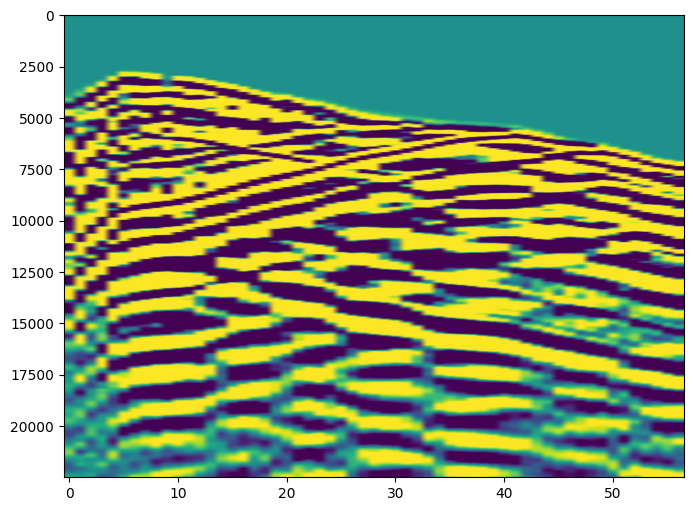

In [49]:
plt.imshow(d_syn_r*scale_factor, aspect='auto', vmin=-1, vmax=1)
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-1, vmax=1)
plt.show()
plt.imshow(d_obs.T-d_syn_r*scale_factor, aspect='auto', vmin=-1, vmax=1)
plt.show()